# Elevation-Bias Diagnostic Grid — walkthrough notebook

This notebook walks through, step by step, how the **5 × 4 elevation-bias
diagnostic figure** is built (rows = model/domain, columns = map, T-bias,
PR-bias, wind-bias scatter).

* **Rows** (5): `D3` = WRF d03, `D15` = WRF d02, `D75` = WRF d01, `CanRCM4`,
  `CanESM2`.
* **Columns** (4): (1) the row's own model topography with station points
  coloured by that row's elevation bias; (2) temperature-bias scatter;
  (3) precipitation-bias scatter; (4) wind-bias scatter.
* In every scatter column, **y = elevation bias (m, −1500…1500)** and
  **x = the variable's bias** (°C / % / %).

The notebook is organised so each logical piece is its own small cell you can
re-run independently: setup → load tables → inspect data → build the grid.
A short **optional** section at the end reproduces the 6 per-dataset
elevation-bias maps from `plot_elev_bias_revised.py`.

> Python: `/home/amh001/space_fs7/software_2022/python/py_2024/bin/python`
> (3.9.19, numpy, pandas, scipy, matplotlib, cartopy, netCDF4).

## 1. Kernel, imports & paths

Everything runs from `BASE`. We import the topography readers
(`read_geo_em` / `read_orog`) from `plot_elev_bias_revised.py` so the two
scripts share the same domain-file parsing. Registering `GeoAxes` lets us
place a Cartopy `GeoAxes` inside a `GridSpec`.

In [1]:
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
from matplotlib.projections import register_projection
from scipy import stats

register_projection(GeoAxes)
warnings.filterwarnings("ignore")

# --- Paths (this workspace) ---------------------------------------------
# Root of the analysis working tree (data/, pickles/, plotting_files/, files/).
# Defaults to the HPC working tree used for the analysis; set
# ELEV_BIAS_BASE to relocate the tree.
BASE = os.environ.get('ELEV_BIAS_BASE',
    '/gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS')
DOMAIN_DIR = os.path.join(BASE, 'plotting_files')
OUT_DIR    = os.path.join(BASE, 'figures', 'elevation_bias')
os.makedirs(OUT_DIR, exist_ok=True)
OUT = os.path.join(OUT_DIR, 'elevation_bias_grid.png')

# Reuse the domain-file readers from the companion script.
sys.path.insert(0, BASE)
from plot_elev_bias_revised import read_geo_em, read_orog

# --- Fonts / rcParams (same as make_elev_bias_grid.py) -------------------
FONT = 10
FONT_S = 9
plt.rcParams.update({
    'font.size': FONT,
    'axes.labelsize': FONT,
    'xtick.labelsize': FONT_S,
    'ytick.labelsize': FONT_S,
    'axes.titlesize': FONT,
    'legend.fontsize': 9,
    'figure.dpi': 150,
})

import matplotlib, cartopy, scipy
print('matplotlib', matplotlib.__version__, '| cartopy', cartopy.__version__,
      '| scipy', scipy.__version__)
for f in ['pickles/station_tables.pkl',
          'plotting_files/geo_em.d01.nc',
          'plotting_files/orog_CanESM2.nc',
          'plotting_files/orog_CanRCM4.nc']:
    p = os.path.join(BASE, f)
    print(f"  {f:35s} {'OK' if os.path.exists(p) else 'MISSING'} "
          f"{os.path.getsize(p)/1e6:8.2f} MB")

ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


Elevation diagnostic: 173 land stations (dropped 11 buoys)
Loaded 173 land stations (ECCC=46, BCH=18, NOAA=109, ECCC-buoys=7, NOAA-buoys=4)


Computing model elevation for each station...


  WARN d03 1001: weight lookup fell back to corner (model_elev=558.4)
  WARN d03 1022: weight lookup fell back to corner (model_elev=837.8)
  WARN d03 1039: weight lookup fell back to corner (model_elev=313.9)
  WARN d03 1043: weight lookup fell back to corner (model_elev=444.0)
  WARN d03 1053: weight lookup fell back to corner (model_elev=404.2)
  WARN d03 1056: weight lookup fell back to corner (model_elev=741.9)
  WARN d03 1074: weight lookup fell back to corner (model_elev=518.3)
  WARN d03 1084: weight lookup fell back to corner (model_elev=644.0)
  WARN d03 118: weight lookup fell back to corner (model_elev=31.6)
  WARN d03 1257: weight lookup fell back to corner (model_elev=504.3)
  WARN d03 1275: weight lookup fell back to corner (model_elev=403.6)
  WARN d03 145: weight lookup fell back to corner (model_elev=102.3)
  WARN d03 153: weight lookup fell back to corner (model_elev=50.5)
  WARN d03 155: weight lookup fell back to corner (model_elev=26.6)
  WARN d03 187: weight look

  WARN d02 1001: weight lookup fell back to corner (model_elev=822.9)
  WARN d02 1022: weight lookup fell back to corner (model_elev=1075.1)
  WARN d02 1039: weight lookup fell back to corner (model_elev=1181.0)
  WARN d02 1043: weight lookup fell back to corner (model_elev=1289.5)
  WARN d02 1053: weight lookup fell back to corner (model_elev=1132.2)
  WARN d02 1056: weight lookup fell back to corner (model_elev=1178.7)
  WARN d02 1074: weight lookup fell back to corner (model_elev=801.8)
  WARN d02 1084: weight lookup fell back to corner (model_elev=981.3)
  WARN d02 118: weight lookup fell back to corner (model_elev=16.5)
  WARN d02 1257: weight lookup fell back to corner (model_elev=1216.7)
  WARN d02 1275: weight lookup fell back to corner (model_elev=937.5)
  WARN d02 145: weight lookup fell back to corner (model_elev=71.7)
  WARN d02 153: weight lookup fell back to corner (model_elev=213.4)
  WARN d02 155: weight lookup fell back to corner (model_elev=6.0)
  WARN d02 187: weight

  WARN d01 1001: weight lookup fell back to corner (model_elev=1124.8)
  WARN d01 1022: weight lookup fell back to corner (model_elev=1205.9)
  WARN d01 1039: weight lookup fell back to corner (model_elev=1317.1)
  WARN d01 1043: weight lookup fell back to corner (model_elev=1261.8)
  WARN d01 1053: weight lookup fell back to corner (model_elev=1124.8)
  WARN d01 1056: weight lookup fell back to corner (model_elev=1265.9)
  WARN d01 1074: weight lookup fell back to corner (model_elev=1124.8)
  WARN d01 1084: weight lookup fell back to corner (model_elev=1178.3)
  WARN d01 118: weight lookup fell back to corner (model_elev=397.9)
  WARN d01 1257: weight lookup fell back to corner (model_elev=1337.1)
  WARN d01 1275: weight lookup fell back to corner (model_elev=1153.2)
  WARN d01 145: weight lookup fell back to corner (model_elev=459.6)
  WARN d01 153: weight lookup fell back to corner (model_elev=1186.1)
  WARN d01 155: weight lookup fell back to corner (model_elev=938.5)
  WARN d01 18

  WARN CanESM2 USC00350595: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00351643: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00351682: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00352325: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00352997: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00353705: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00355384: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00355971: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00356749: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00357466: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00357641: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00358494: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanESM2 USC00358884: no weight file -> nearest-GP (model_elev=119.3)
  WARN CanES

  WARN CanRCM4 USC00350595: no weight file -> nearest-GP (model_elev=122.4)
  WARN CanRCM4 USC00351643: no weight file -> nearest-GP (model_elev=237.5)
  WARN CanRCM4 USC00351682: no weight file -> nearest-GP (model_elev=155.1)
  WARN CanRCM4 USC00352325: no weight file -> nearest-GP (model_elev=184.7)
  WARN CanRCM4 USC00352997: no weight file -> nearest-GP (model_elev=184.7)
  WARN CanRCM4 USC00353705: no weight file -> nearest-GP (model_elev=302.6)
  WARN CanRCM4 USC00355384: no weight file -> nearest-GP (model_elev=187.7)
  WARN CanRCM4 USC00355971: no weight file -> nearest-GP (model_elev=201.1)
  WARN CanRCM4 USC00356749: no weight file -> nearest-GP (model_elev=122.4)
  WARN CanRCM4 USC00357466: no weight file -> nearest-GP (model_elev=175.7)
  WARN CanRCM4 USC00357641: no weight file -> nearest-GP (model_elev=109.7)
  WARN CanRCM4 USC00358494: no weight file -> nearest-GP (model_elev=278.5)
  WARN CanRCM4 USC00358884: no weight file -> nearest-GP (model_elev=279.2)
  WARN CanRC

## 2. Load the station tables (pickle)

`pickles/station_tables.pkl` is a dict of **5 DataFrames** (one per row /
dataset), each with **175 rows** (one per station) and 8 columns. The bias
columns are `NaN` where a given dataset has no per-station value (e.g. D01
has no wind, BCH stations have no WRF per-station file).

In [2]:
with open(os.path.join(BASE, 'pickles', 'station_tables.pkl'), 'rb') as f:
    tables = pickle.load(f)

print('datasets :', list(tables.keys()))
print('rows     :', {k: len(v) for k, v in tables.items()})
print('columns  :', list(tables['D03'].columns))

datasets : ['D03', 'D02', 'D01', 'CanESM2', 'CanRCM4']
rows     : {'D03': 175, 'D02': 175, 'D01': 175, 'CanESM2': 175, 'CanRCM4': 175}
columns  : ['station', 'lat', 'lon', 'obs_elev_m', 'elevation_bias_m', 'elev_method', 'temperature_bias_C', 'precipitation_bias_pct', 'wind_bias_pct']


## 3. Inspect the data

A quick look at the D03 table and a **bias-completeness summary** (how many
stations have a non-NaN value in each bias column). Note the rows that are
populated in the figure: T in all rows, PR in all but D75, wind only in
D3/D15/CanRCM4/CanESM2 (D75 has none).

In [3]:
pd.set_option('display.width', 160)
tables['D03'].head(5)

,station,lat,lon,obs_elev_m,elevation_bias_m,elev_method,temperature_bias_C,precipitation_bias_pct,wind_bias_pct
0,82,48.59,-124.33,10.00,273.304748,bicubic,-1.879982,1269.311683,NaN
1,87,48.62,-123.42,61.00,-43.314888,bicubic,-0.605954,1578.081975,NaN
2,93,48.89,-123.55,45.70,-11.043945,bicubic,-0.816901,1556.567187,NaN
3,97,48.65,-123.63,159.00,-40.448984,bicubic,-0.680934,1692.417775,NaN
4,118,48.65,-123.43,19.51,-13.276505,bicubic,-0.266998,1577.183976,13.957461


In [4]:
comp = pd.DataFrame({
    'n_temp':  [int((~v['temperature_bias_C'].isna()).sum())   for v in tables.values()],
    'n_pr':    [int((~v['precipitation_bias_pct'].isna()).sum()) for v in tables.values()],
    'n_wind':  [int((~v['wind_bias_pct'].isna()).sum())         for v in tables.values()],
    'n_elevbias': [int((~v['elevation_bias_m'].isna()).sum())   for v in tables.values()],
}, index=list(tables.keys()))
comp['n_total'] = 175
comp

,n_temp,n_pr,n_wind,n_elevbias,n_total
D03,147,164,18,164,175
D02,147,164,17,164,175
D01,146,163,17,164,175
CanESM2,147,164,18,164,175
CanRCM4,147,164,18,164,175


## 4. Methods & equations

What the numbers on the figure actually are, before the drawing code.

**Station set.** 175 stations (ECCC + BCH + NOAA land + ECCC/NOAA buoys;
buoys forced to 0 m elevation). Each station *i* has observed coordinates
$(\phi_i, \lambda_i)$ and observed elevation $z_i^{\text{obs}}$.

**1. Elevation bias (the y-axis of every scatter).** For a model topography
field $h$ on a lat/lon grid, the modeled elevation is the nearest grid node
by Chebyshev (max) distance in degrees:

$$d_{jk}=\max\big(|\phi_i-\phi^{grid}_{jk}|\;,\;|\lambda_i-\lambda^{grid}_{jk}|\big),\quad (j^*,k^*)=\arg\min_{jk} d_{jk}$$
$$z_i^{\text{model}} = h_{j^*k^*},\qquad \boxed{\,b_i = z_i^{\text{model}} - z_i^{\text{obs}}\,}$$

Exact nearest-neighbor, no interpolation, no spherical correction. The dot
color is $b_i$ on a symmetric diverging PRGn scale (`TwoSlopeNorm`, 0 at
center, ±1500 m). Summary stats: mean $\bar b=\frac1N\sum_i b_i$ and
$\text{RMS}=\sqrt{\frac1N\sum_i b_i^2}$ (root-mean-square of the bias, not a
regression RMSE — includes the mean, so RMS ≥ |mean|).

**2. Variable biases (the x-axes).** For each variable $V$,
$\text{bias}^V_i = V^{\text{model}}_i - V^{\text{obs}}_i$ (annual means /
totals, 1986–2005). Temperature is in °C; precipitation and wind are
**percent biases**:

$$\text{bias}^V_i = \frac{V^{\text{model}}_i - V^{\text{obs}}_i}{V^{\text{obs}}_i}\times 100$$

The division by $V^{\text{obs}}_i$ is why D01 precipitation explodes
(dry stations → small denominator → huge %). A station appears in a scatter
only where *both* $b_i$ and $\text{bias}^V_i$ are non-NaN.

**3. OLS fit + R² (each scatter).** With $x_i=\text{bias}^V_i$ (variable
bias) and $y_i=b_i$ (elevation bias), fit $y=\beta_0+\beta_1 x$:

$$\hat\beta_1 = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2},\qquad \hat\beta_0=\bar y-\hat\beta_1\bar x$$

$$\boxed{\;R^2 = r_{xy}^{\,2} = \left[\frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\,\sqrt{\sum_i (y_i-\bar y)^2}}\right]^{2}\;}$$

`scipy.stats.linregress` returns this $r$ (the slope's r-value). Because it's
a 2-variable OLS, $R^2=r_{xy}^2$ is **symmetric** in x and y — the reported
number does not depend on which bias you regress on; only the fit *line's*
slope/orientation does. (Open item: if Eva's original defined R differently,
swap the ~10-line fit block.)

**4. Map column (topography rendering).** WRF `geo_em` stores `XLAT_C`/
`XLONG_C` as cell *corners* $(n_y+1,n_x+1)$ but `HGT_M` as cell *centres*
$(n_y,n_x)$, so centre coords are midpoints
$\phi^c_i=\tfrac12(\phi_i+\phi_{i+1})$, $\lambda^c_j=\tfrac12(\lambda_j+\lambda_{j+1})$.
All five rows are masked to a shared extent and drawn on a **shared terrain
scale** $[\min h,\max h]$ so color is comparable and resolution differences
are visible. Crosshairs on the scatters are the $x=0$, $y=0$ "no bias" origin.


## 4a. Note: extraction-consistent model orography (supersedes the nearest-GP formula above)

The nearest-grid-point formula in §4 is shown for reference. The pickle this
notebook loads (`pickles/station_tables.pkl`) uses the **extraction-consistent**
model orography: because every model series was extracted by `cdo remap` with a
specific bicubic weight file (recorded in the T file's `history`), the model
elevation is the *same CDO remap applied to orography*:

$$\text{model\_elev} = \sum_k w_k \cdot \text{orog}[i_k, j_k],\qquad (i_k,j_k)=\mathrm{divmod}(\text{src\_address}_k, n_x)$$

with $w_k$ the station column of the weight file (weights sum to 1.0). This
removes the nearest-grid-point stacking artefact (the old "vertical line" in the
CanRCM4 PR panel) and shows the coarse-grid over-elevation at its true
magnitude. The per-row `elev_method` column records `bicubic` vs the
nearest-grid-point / cell-centre **fallback** used for the few stations with no
weight file. Full method, sign conventions and the NOAA-inches unit note are in
`results/elev_bias_methods_math.md`; the working-tree
`elevation_bias_handoff.md` has the full bug-fix + verification log.


## 5. Build the 5 × 4 grid figure

This is the core drawing routine (inlined from `make_elev_bias_grid.py`).
It:
1. Loads each row's own topography (WRF `geo_em` d01–d03 from `HGT_M`;
   CanESM2/CanRCM4 from their `orog` files), all masked to a shared map
   extent so the resolution differences are visible.
2. Lays out a `GridSpec` (5 rows × 4 cols) and fills it:
   * **col 1** — `pcolormesh` of that row's topography + station points
     coloured by that row's elevation bias (PRGn, two-slope at 0).
   * **cols 2–4** — scatter of variable-bias (x) vs elevation-bias (y),
     with OLS fit line + Pearson R², origin crosshairs, and tick-label
     culling so labels sit on the exterior edges of each column block.
3. Adds bold rotated row labels, panel tags (a)–(t), two horizontal
   colorbars under the map column, the D75-row emphasis, and the suptitle.

Run it to render the figure inline and save it to
`figures/elevation_bias/elevation_bias_grid.png`.
Set the env var `GRID_DEBUG=1` before running to print a per-panel
tick-label visibility report (same hook as the script).

In [5]:
# --- Row / column definitions -------------------------------------------
ROWS = [
    ('D3',      'D03',     '#1f77b4', ('wrf',  'geo_em.d03.nc')),   # blue
    ('D15',     'D02',     '#ff7f0e', ('wrf',  'geo_em.d02.nc')),   # orange
    ('D75',     'D01',     '#2ca02c', ('wrf',  'geo_em.d01.nc')),   # green (emphasised)
    ('CanRCM4', 'CanRCM4', '#9467bd', ('orog', 'orog_CanRCM4.nc')), # purple
    ('CanESM2', 'CanESM2', '#d62728', ('orog', 'orog_CanESM2.nc')), # red
]
COLS = [
    ('elev', 'Model topography',        None,  None),
    ('t',    'Temperature bias (°C)',   -17.5, 12.5),
    ('pr',   'Precipitation bias (%)',  -400,  400),
    ('wind', 'Wind speed bias (%)',     -175.0, 575.0),
]
MAP_EXTENT = [-132, -115, 43, 55]

# --- Per-row topography (masked to a shared extent) ----------------------
def _wrf_topo(fname):
    """geo_em d0X: XLAT_C/XLONG_C are (ny+1, nx+1) cell corners; HGT_M is
    (ny, nx) cell centres. Pass 2D corners straight to pcolormesh — the grid
    is curvilinear (map-projected), so it cannot be reduced to 1D axes."""
    lat_c, lon_c, topo = read_geo_em(fname)

    # Approximate cell-center coords (2D) just for masking to MAP_EXTENT
    lat_ctr = 0.25 * (lat_c[:-1, :-1] + lat_c[1:, :-1] + lat_c[:-1, 1:] + lat_c[1:, 1:])
    lon_ctr = 0.25 * (lon_c[:-1, :-1] + lon_c[1:, :-1] + lon_c[:-1, 1:] + lon_c[1:, 1:])

    m = (lat_ctr >= MAP_EXTENT[2] - 0.5) & (lat_ctr <= MAP_EXTENT[3] + 0.5) & \
        (lon_ctr >= MAP_EXTENT[0] + 0.5) & (lon_ctr <= MAP_EXTENT[1] - 0.5)

    # Return full 2D corner arrays (not 1D!) for pcolormesh; topo masked at centers.
    return lon_c, lat_c, np.ma.masked_where(~m, topo)

def _orog_topo(fname):
    lats, lons, topo = read_orog(fname)
    m = (lats >= MAP_EXTENT[2] - 0.5) & (lats <= MAP_EXTENT[3] + 0.5) & \
        (lons >= MAP_EXTENT[0] + 0.5) & (lons <= MAP_EXTENT[1] - 0.5)
    return lons, lats, np.ma.masked_where(~m, topo)

topos = {}
for row_label, _, _, (kind, fname) in ROWS:
    topos[row_label] = _wrf_topo(fname) if kind == 'wrf' else _orog_topo(fname)

_all_topo = np.concatenate([t[2].compressed() for t in topos.values()])
TOPO_VMIN, TOPO_VMAX = float(np.min(_all_topo)), float(np.max(_all_topo))
cmap_topo = cm.get_cmap('terrain', 16)

BIAS_VMIN, BIAS_VMAX = -1500, 1500
cmap_bias = cm.get_cmap('PRGn', 24)

print(f'Topo scale: {TOPO_VMIN:.0f} .. {TOPO_VMAX:.0f} m')

Topo scale: 0 .. 3234 m


Saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/elevation_bias_grid.png


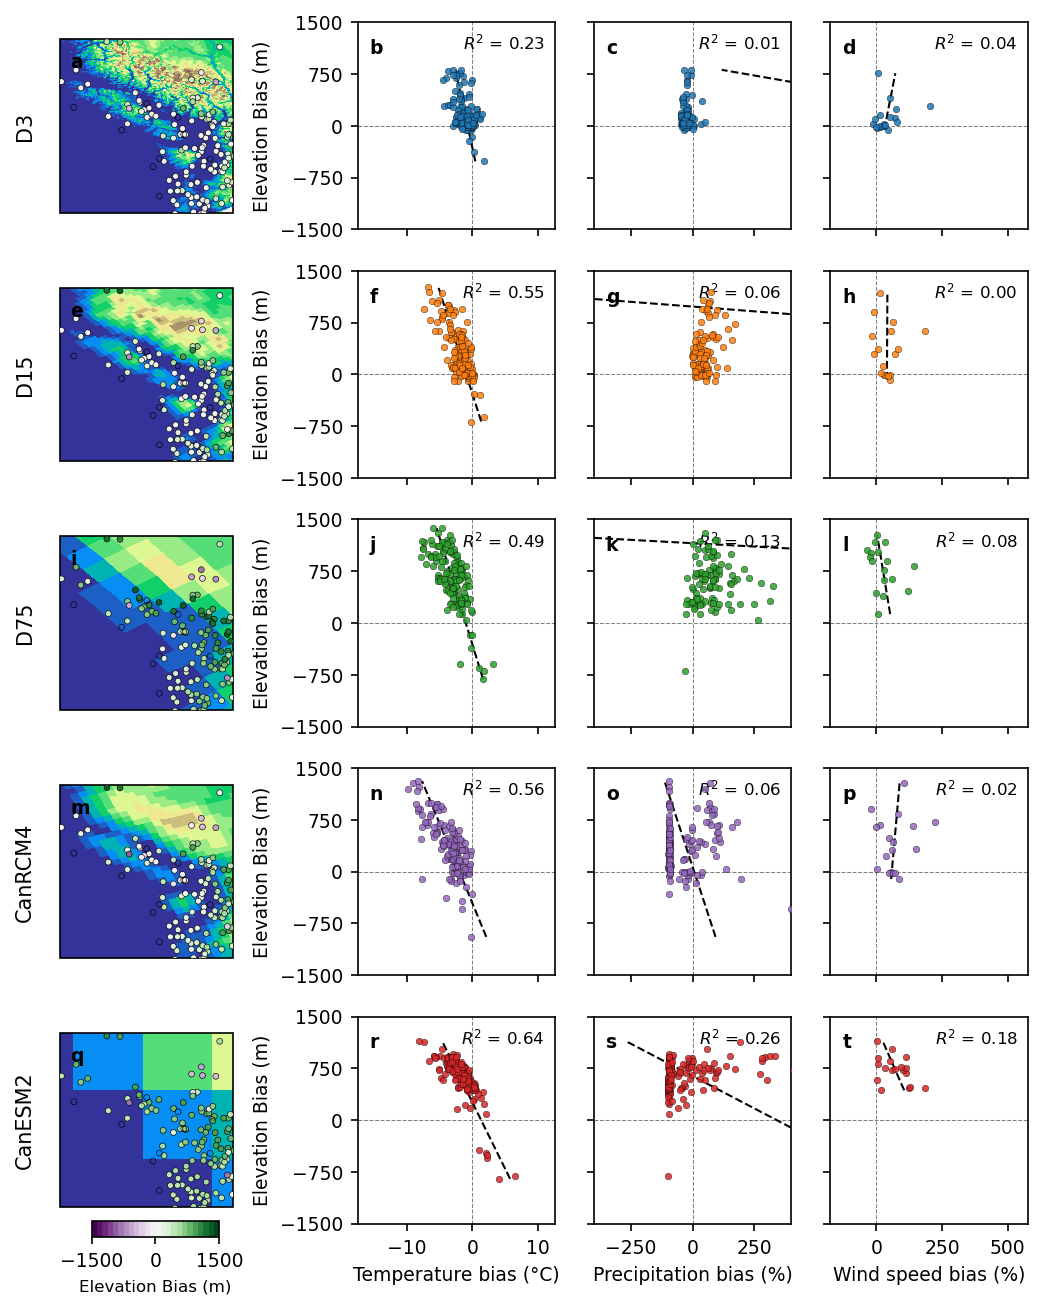

In [6]:
import matplotlib.patches as mpatches

# --- Style constants, matched to the reference figure -----------------------
FONT   = 9
FONT_S = 8
TAG_BOX = dict(boxstyle='square,pad=0.25', fc='white', ec='black', lw=0.8)

n_rows, n_cols = len(ROWS), len(COLS)
panel_tag = 0
def next_tag():
    global panel_tag
    tag = chr(ord('a') + panel_tag)
    panel_tag += 1
    return tag

# --- Tight, shared map extent (elevation-map column only) -------------------
def get_tight_extent(lons, lats, pad_frac=0.06):
    """Compute a tight bounding box from actual coordinates, with a small
    padding fraction so points/edges aren't clipped against the axes frame."""
    lon_min, lon_max = np.nanmin(lons), np.nanmax(lons)
    lat_min, lat_max = np.nanmin(lats), np.nanmax(lats)
    lon_pad = (lon_max - lon_min) * pad_frac
    lat_pad = (lat_max - lat_min) * pad_frac
    return [lon_min - lon_pad, lon_max + lon_pad,
            lat_min - lat_pad, lat_max + lat_pad]

# --- Shared map extent = extent of the FIRST row's topography ---------------
# All rows use this same window so every elevation-map panel is at the same
# zoom level, anchored to the first row's topo tile coverage.
first_row_label = ROWS[0][0]
tlons0, tlats0, _ = topos[first_row_label]
#SHARED_EXTENT = get_tight_extent(tlons0, tlats0, pad_frac=0.01)

# --- Figure + GridSpec ------------------------------------------------------
# NOTE: the map column (col 1) is placed with MANUAL figure-level axes (below),
# NOT from the GridSpec, so we can make the gap between the map and the T column
# TWICE the gap between the scatter columns.  GridSpec gaps are always uniform
# (all = wspace * mean_col_width), so width_ratios alone cannot do this.
fig = plt.figure(figsize=(7.09, 8.9))   # 180mm max Wiley width, safe depth
gs = gridspec.GridSpec(
    n_rows, 3,                        # scatter columns only (t, pr, wind)
    left=0.34, right=0.97, top=0.98, bottom=0.08,
    wspace=0.2, hspace=0.20,
    width_ratios=[1, 1, 1],
)
fig.canvas.draw()                     # resolve positions so we can anchor the map
_sc_pos0 = gs[0, 0].get_position(fig) # first scatter column (T)
_sc_gap  = 0.30 * _sc_pos0.width      # one scatter-column gap (wspace * col width)
MAP_X0 = 0.06                         # map left margin (rotated row labels live left of this)
MAP_X1 = _sc_pos0.x0 - 2.1 * _sc_gap  # map right edge: 2x gap before the T column

row_axes_first_col = []  # to draw the D75 highlight box around later

for ri, (row_label, table_key, row_color, _) in enumerate(ROWS):
    df = tables[table_key]
    elev      = df['elevation_bias_m'].values
    t_bias    = df['temperature_bias_C'].values
    pr_bias   = df['precipitation_bias_pct'].values
    wind_bias = df['wind_bias_pct'].values
    lats = df['lat'].values
    lons = df['lon'].values
    is_d75 = (row_label == 'D75')

    row_ax_list = []

    for ci, (col_key, col_label, xmin, xmax) in enumerate(COLS):
        if col_key == 'elev':
            # Manual figure-level axes: x from MAP_X0..MAP_X1, y/height from the
            # GridSpec row so the map lines up vertically with the scatter row.
            _row_pos = gs[ri, 0].get_position(fig)
            ax = GeoAxes(fig, [MAP_X0, _row_pos.y0, MAP_X1 - MAP_X0, _row_pos.height],
                         projection=ccrs.PlateCarree())
            fig.add_axes(ax)
        else:
            ax = fig.add_subplot(gs[ri, ci - 1])   # scatter cols are gs cols 0..2
        row_ax_list.append(ax)

        tag = next_tag()
        # --- boxed bold panel tag, matching reference: (a), (b), ... ---
        ax.text(0.06, 0.92, f'{tag}', transform=ax.transAxes,
                fontweight='bold', fontsize=FONT, color='black',
                ha='left', va='top', zorder=1000)

        if col_key == 'elev':
            ax.set_facecolor('#f0f0f0')
            tlons, tlats, ttopo = topos[row_label]
            ax.pcolormesh(tlons, tlats, ttopo, cmap=cmap_topo,
                          vmin=TOPO_VMIN, vmax=TOPO_VMAX,
                          transform=ccrs.PlateCarree())
            #ax.gridlines(draw_labels=False, linewidth=0.3, color='grey',
                      #  alpha=0.5, linestyle=':')

            # --- shared extent, taken from row 1's topo coverage ---
            #ax.set_extent(SHARED_EXTENT, crs=ccrs.PlateCarree())
            ax.set_extent([-128.5, -121.5, 45.5, 52.5], crs=ccrs.PlateCarree())
            #ax.set_extent([-127.4, -122.7, 46.6, 51.35], crs=ccrs.PlateCarree())
            mesh_bias = ax.scatter(lons, lats, c=elev, s=8, cmap=cmap_bias,
                            norm=mcolors.TwoSlopeNorm(vmin=BIAS_VMIN, vcenter=0,
                                                      vmax=BIAS_VMAX),
                            edgecolors='k', linewidths=0.3, zorder=5,
                            transform=ccrs.PlateCarree())
            #ax.set_aspect('equal')

            # --- colored row label, outside the map, matching reference ---
            
            ax.text(-0.2, 0.5, row_label, transform=ax.transAxes,
                    fontsize=FONT + 1, fontweight='normal', color='k',
                    ha='center', va='center', rotation='vertical')
        else:
            var = {'t': t_bias, 'pr': pr_bias, 'wind': wind_bias}[col_key]
            m = ~np.isnan(elev) & ~np.isnan(var)
            xs, ys = var[m], elev[m]
            n_pts = len(xs)

            ax.scatter(xs, ys, s=10, color=row_color, edgecolors='k',
                       linewidths=0.2, zorder=5, alpha=0.85)
            ax.axhline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)
            ax.axvline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)

            if n_pts >= 3:
                slope, intercept, r_value, p_value, std_err = stats.linregress(ys, xs)
                y_fit = np.linspace(ys.min(), ys.max(), 100)
                ax.plot(slope * y_fit + intercept, y_fit, 'k--', linewidth=1, zorder=4)
                r2 = r_value ** 2
                # --- plain black R² text, no box, top-right, matching reference ---
                ax.text(0.95, 0.95, f'$R^2$ = {r2:.2f}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=FONT_S, color='black')

            ax.set_xlim(xmin, xmax)
            ax.set_ylim(-1500, 1500)
            ax.set_yticks([-1500, -750, 0, 750, 1500])

            if col_key == 't':
                if ri < n_rows - 1:
                    for lbl in ax.get_xticklabels():
                        lbl.set_visible(False)
                # y-tick labels shown on temperature column only (per reference)
            else:
                for lbl in ax.get_yticklabels():
                    lbl.set_visible(False)
                if ri < n_rows - 1:
                    for lbl in ax.get_xticklabels():
                        lbl.set_visible(False)

        if col_key != 'elev':
            if ri == n_rows - 1:
                ax.set_xlabel(col_label, fontsize=FONT)
            if col_key == 't':
                ax.set_ylabel('Elevation Bias (m)', fontsize=FONT)

        if ri == n_rows - 1 and col_key == 'elev':
            ax.set_xlabel('Longitude (°W)', fontsize=FONT)

        # consistent thin black spine on every panel
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color('black')

    row_axes_first_col.append(row_ax_list)

# --- Draw a black highlight box around the D75 row, like the reference ------
d75_ri = [i for i, r in enumerate(ROWS) if r[0] == 'D75'][0]
row_ax_list = row_axes_first_col[d75_ri]
x0 = min(a.get_position().x0 for a in row_ax_list)
x1 = max(a.get_position().x1 for a in row_ax_list)
y0 = min(a.get_position().y0 for a in row_ax_list)
y1 = max(a.get_position().y1 for a in row_ax_list)
pad = 0.006

# --- Single shared colorbar for elevation bias, matching reference ----------
cbar_ax = fig.add_axes([0.09, 0.07, 0.12, 0.012])
cbar = fig.colorbar(mesh_bias, cax=cbar_ax, orientation='horizontal',
                     ticks=[-1500, 0,  1500])
cbar.set_label('Elevation Bias (m)', fontsize=FONT_S)
cbar.outline.set_linewidth(0.8)

fig.savefig(OUT, dpi=600)
print(f'Saved {OUT}')

## 5b. Precipitation bias in absolute units (mm/day)The 5×4 grid above shows PR bias as a **percent**. Percent bias is a ratio, so anydataset whose model precipitation falls below ~2% of observations piles all itsstations onto the −100% axis floor — that is the vertical band seen in the CanRCM4and CanESM2 panels (both are raw GCM-scale precip, ~1–3 kmm/yr vs ~17–30 kmm/yrobserved at the wet interior/coastal stations). It is a real, large dry bias, not aplotting artefact.This cell re-plots the same station set with the **absolute** PR bias$(\text{model} - \text{obs})$ in **mm/day**, which removes the ratio floor: the sameCanRCM4/CanESM2 stations now spread over ≈ −205…0 mm/day according to how wettheir station is.Per-station absolute bias is recovered from the pickle *without a rebuild*:$$\text{abs\_bias\_{mm/day}} = \frac{\text{pct}}{100}\times\frac{obs\_{mm/day}}{}$$i.e. $(\text{pct}/100)\times obs$, with `obs` the 1986–2005 annual-mean observedprecipitation **per day** (annual mm/yr ÷ 365). `obs_mm/day` is recomputed herefrom the raw obs files (ECCC daily totals, NOAA GHCN-d PRCP inches ×25.4, BCH p24)— the identical loaders used by `make_station_tables.py` — cached in`pickles/obs_pr_mm_annual.pkl` so repeated runs are seconds, not minutes.Caveat: D01's ECCC stations carry the very large +2,000–7,000 % biases noted in §5,so D01's absolute bias is dominated by those same stations; the x-range is wide(−220…+220 mm/day). NOAA-only medians: D03 ≈ −22, D02 ≈ +25, D01 ≈ +42,CanESM2 ≈ −78, CanRCM4 ≈ −78 mm/day.

Loaded obs PR (mm/day) from cache: /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/pickles/obs_pr_mm_annual.pkl
  obs PR available for 164 stations
  D03      implied model PR: median    202996 mm/yr (min      3565, max   1731356)
  D02      implied model PR: median    438439 mm/yr (min      8901, max   2756261)
  D01      implied model PR: median    764854 mm/yr (min     17279, max   1860037)
  CanESM2  implied model PR: median     23249 mm/yr (min       853, max     38927)
  CanRCM4  implied model PR: median     16427 mm/yr (min       374, max     80563)
Saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/elevation_bias_grid_pr_abs.png


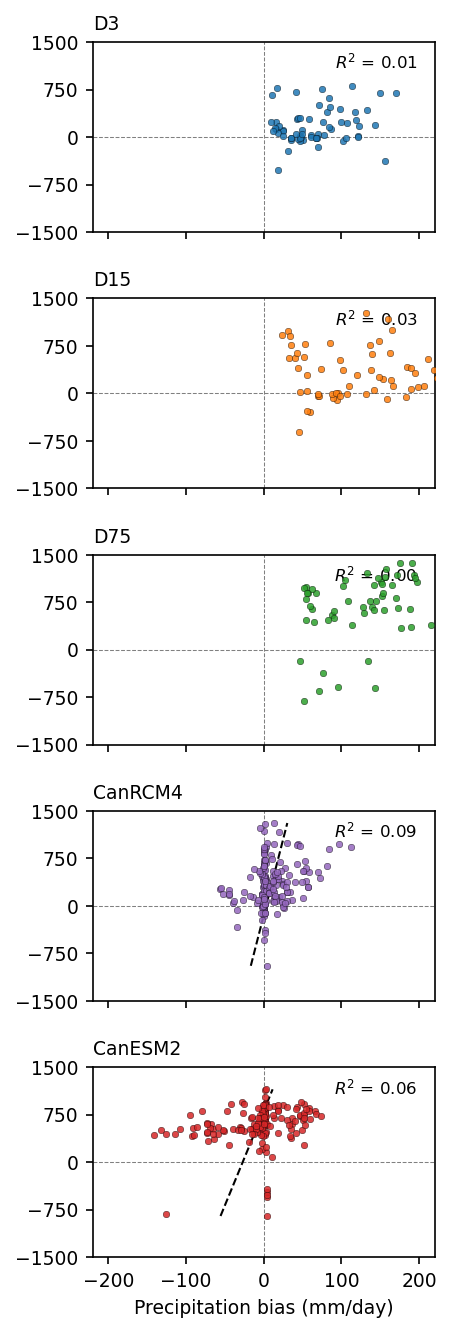

In [14]:
# --- Absolute PR bias (mm/day) -------------------------------------------
# Re-plot the 5 rows of PR bias as (model - obs) in mm/day instead of %.
# abs_bias = (pct/100) * obs_mm/day  -- exact, verified below.
# obs: 1986-2005 annual-mean precip in mm/day (annual mm/yr / 365).
# Fast path: precomputed cache pickles/obs_pr_mm_annual.pkl (built once from
# the raw obs files, same loaders as make_station_tables.py). Fallback below
# recomputes from raw.
import glob as _glob
import datetime as _dt

DATA = os.path.join(BASE, 'data')
NOAA_OBS_DIR = os.path.join(DATA, 'noaa_obs')
ECCC_OBS_DIR = os.path.join(DATA, 'eccc_obs')
BCH_OBS_DIR  = os.path.join(DATA, 'bch_obs')
TENTHS_MM_BCH = {'BLN', 'DLU', 'MIS', 'NTY', 'WOL'}   # BCH p24 in tenths of mm
OBS_PR_CACHE = os.path.join(BASE, 'pickles', 'obs_pr_mm_annual.pkl')

def _noaa_pr_obs_all():
    cols = ['STATION', 'DATE', 'TAVG', 'TMIN', 'TMAX', 'PRCP', 'AWND']
    files = [os.path.join(NOAA_OBS_DIR, f'{y0}-{y0+4}.csv') for y0 in (1986, 1991, 1996, 2001)]
    df = pd.concat([pd.read_csv(p, usecols=cols, low_memory=False) for p in files],
                   ignore_index=True)
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df[(df['DATE'] >= _dt.datetime(1986, 1, 1)) & (df['DATE'] < _dt.datetime(2006, 1, 1))]
    out = {}
    for s, g in df.groupby('STATION'):
        g = g.copy()
        g['PRCP'] = pd.to_numeric(g['PRCP'], errors='coerce')
        s_ = g['PRCP'].dropna()
        if len(s_):
            out[s] = float(s_.groupby(g.loc[s_.index, 'DATE'].dt.year).sum().mean() * 25.4)
    return out

def _eccc_pr_obs(sid):
    d = os.path.join(ECCC_OBS_DIR, str(sid))
    if not os.path.isdir(d):
        return np.nan
    files = []
    for y in (1986, 1987, 1988, 1989, 1990, 2001, 2002, 2003, 2004, 2005):
        files += _glob.glob(os.path.join(d, f'*_{y}_P1D.csv'))
    if not files:
        return np.nan
    dfs = []
    for f in files:
        try:
            x = pd.read_csv(f, usecols=['Date/Time', 'Total Rain (mm)'],
                            encoding='utf-8-sig').dropna()
            dfs.append(x)
        except Exception:
            pass
    if not dfs:
        return np.nan
    x = pd.concat(dfs, ignore_index=True)
    x['Date/Time'] = pd.to_datetime(x['Date/Time'])
    x = x[(x['Date/Time'] >= _dt.datetime(1986, 1, 1)) &
          (x['Date/Time'] <  _dt.datetime(2006, 1, 1))]
    v = x['Total Rain (mm)'].astype(float)
    return float(v.groupby(x['Date/Time'].dt.year).sum().mean())

def _bch_pr_obs(sid):
    pmin = os.path.join(BCH_OBS_DIR, f'BCH_p24{sid}.csv')
    wide = os.path.join(BCH_OBS_DIR, 'BCH_p24Id.csv')
    d = pd.read_csv(pmin if os.path.exists(pmin) else wide, index_col=0)
    d.index = pd.to_datetime(d.index).tz_localize(None)
    s = d[sid].dropna()
    if sid in TENTHS_MM_BCH:
        s = s / 10.0
    return float(s.groupby(s.index.year).sum().mean())

# --- load obs PR: cache (seconds) or recompute from raw (~1 min) ---------
try:
    with open(OBS_PR_CACHE, 'rb') as f:
        _c = pickle.load(f)
    obs_pr = {k: v / 365.0 for k, v in _c['obs_pr_mm'].items()}   # mm/yr -> mm/day
    print(f"Loaded obs PR (mm/day) from cache: {OBS_PR_CACHE}")
except Exception:
    print('No cache found - recomputing obs PR from raw files (~1 min)...')
    _noaa_all = _noaa_pr_obs_all()
    obs_pr = {}
    for _s in tables['D03']['station']:
        s = str(_s)
        if s.isdigit():
            obs_pr[_s] = _eccc_pr_obs(_s)
        elif s.startswith('US'):
            obs_pr[_s] = _noaa_all.get(s, np.nan)
        else:
            try:
                obs_pr[_s] = _bch_pr_obs(_s)
            except Exception:
                obs_pr[_s] = np.nan
    obs_pr = {k: (v / 365.0 if not pd.isna(v) else np.nan) for k, v in obs_pr.items()}
print(f"  obs PR available for {sum(1 for v in obs_pr.values() if not pd.isna(v))} stations")

# --- per-dataset absolute PR bias (mm/day) ------------------------------
abs_pr = {}
for _k, _df in tables.items():
    _o = np.array([obs_pr[s] for s in _df['station']], dtype=float)
    _p = _df['precipitation_bias_pct'].values.astype(float)
    abs_pr[_k] = np.where(np.isfinite(_o) & np.isfinite(_p), (_p / 100.0) * _o, np.nan)

# sanity check: abs = pct/100*obs  <=>  implied model = obs*(1+pct/100);
# print implied model PR range as a plausibility check (must be > 0,
# climatologically sensible).
for _k in tables:
    _o = np.array([obs_pr[s] for s in tables[_k]['station']], dtype=float)
    _p = tables[_k]['precipitation_bias_pct'].values.astype(float)
    _m = np.isfinite(_o) & np.isfinite(_p)
    _model = _o[_m] * (1 + _p[_m] / 100.0) * 365.0     # back to mm/yr for reading
    print(f'  {_k:8s} implied model PR: median {np.median(_model):9.0f} mm/yr '
          f'(min {_model.min():9.0f}, max {_model.max():9.0f})')

# --- figure: 5 rows x 1 column, absolute PR bias vs elevation bias ------
OUT_ABS = os.path.join(OUT_DIR, 'elevation_bias_grid_pr_abs.png')
x_lo, x_hi = -220.0, 220.0   # mm/day

fig = plt.figure(figsize=(3.4, 8.9))
gs = gridspec.GridSpec(len(ROWS), 1, left=0.30, right=0.97, top=0.97,
                       bottom=0.06, hspace=0.35)
for ri, (row_label, table_key, row_color, _) in enumerate(ROWS):
    _df = tables[table_key]
    elev = _df['elevation_bias_m'].values
    xs = abs_pr[table_key]
    ax = fig.add_subplot(gs[ri, 0])
    m = ~np.isnan(elev) & ~np.isnan(xs)
    ax.scatter(xs[m], elev[m], s=10, color=row_color, edgecolors='k',
               linewidths=0.2, zorder=5, alpha=0.85)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)
    if m.sum() >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(elev[m], xs[m])
        y_fit = np.linspace(elev[m].min(), elev[m].max(), 100)
        ax.plot(slope * y_fit + intercept, y_fit, 'k--', linewidth=1, zorder=4)
        ax.text(0.95, 0.95, f'$R^2$ = {r_value**2:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=FONT_S, color='black')
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(-1500, 1500)
    ax.set_yticks([-1500, -750, 0, 750, 1500])
    ax.set_title(row_label, fontsize=FONT, loc='left')
    if ri < len(ROWS) - 1:
        for lbl in ax.get_xticklabels():
            lbl.set_visible(False)
    else:
        ax.set_xticks([-200, -100, 0, 100, 200])
        ax.set_xlabel('Precipitation bias (mm/day)', fontsize=FONT)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('black')
fig.savefig(OUT_ABS, dpi=600)
print(f'Saved {OUT_ABS}')
plt.show()


## 5c. Full 5 × 4 diagnostic grid with absolute PR bias (mm/day)The complete remake of the §5 figure — all **20 panels** (5 rows × 4 columns:topography map, temperature bias, precipitation bias, wind bias) — with theprecipitation column re-expressed as **absolute** bias (model − obs, mm/day)instead of percent. Everything else (layout, map column, T and wind columns,elevation-bias colouring, OLS + R², D75 highlight box, shared colourbar) isidentical to §5, so the two figures differ *only* in the PR column.Use this figure when you want to judge precipitation performance in physicalunits: it avoids the −100% ratio-floor pile-up of CanRCM4/CanESM2 and keeps theWRF rows on an honest absolute scale. The PR x-range is −220…+220 mm/day(≈ ∓80 kmm/yr).

Saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/elevation_bias_grid_pr_abs_full.png


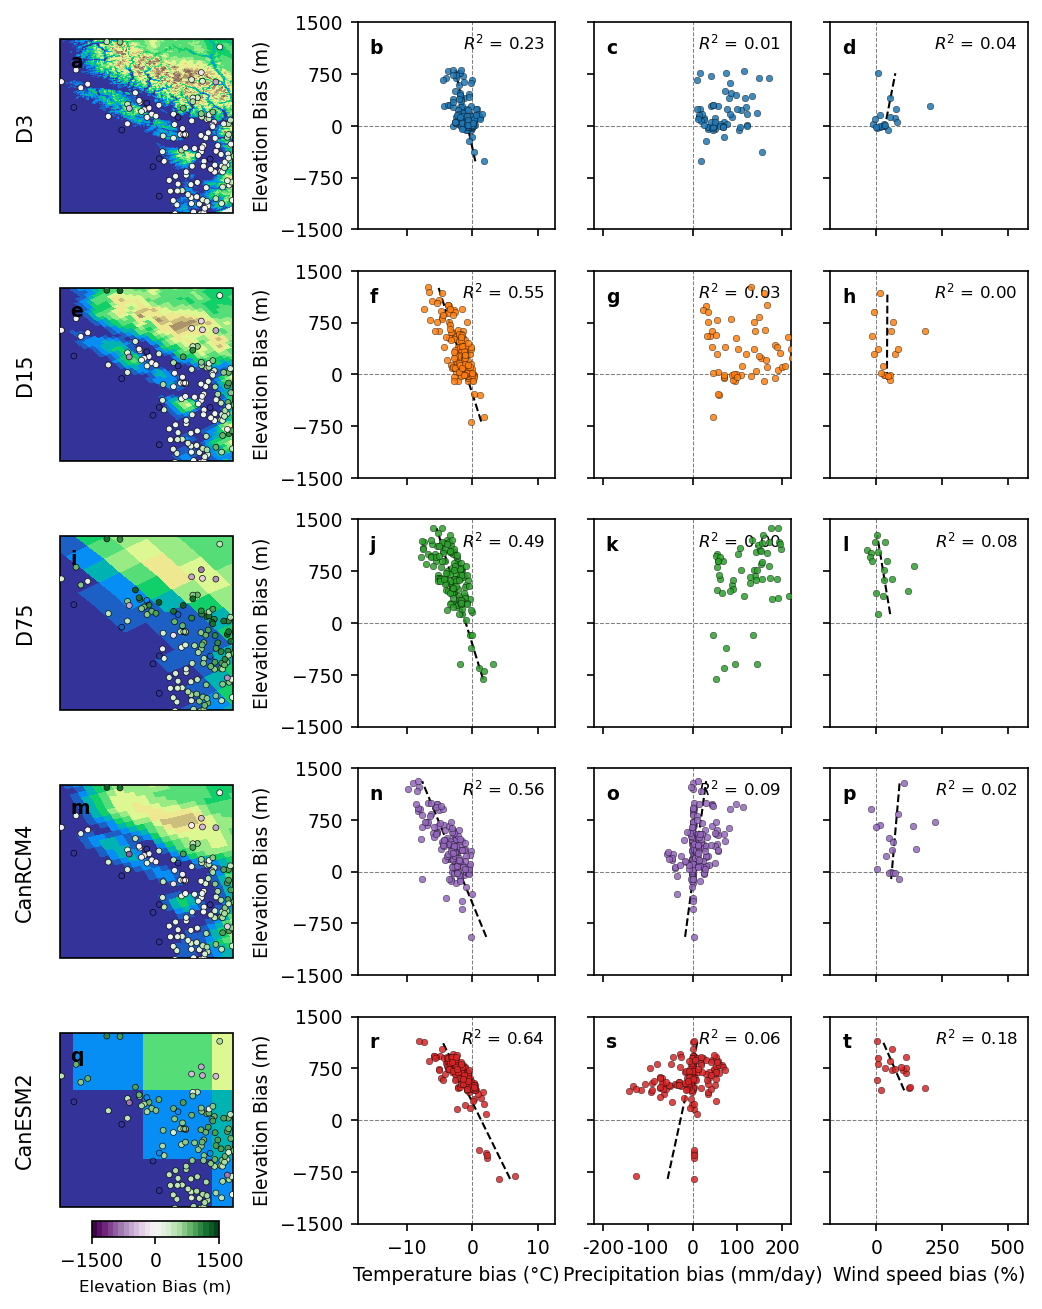

In [15]:
# --- Full 5 x 4 grid, PR column in absolute units (mm/day) ---------------
# Remake of the §5 figure with ONLY the PR column changed from % to
# (model - obs) in mm/day. Reuses `abs_pr` (mm/day) and `obs_pr` computed in §5b.
OUT_ABS_GRID = os.path.join(OUT_DIR, 'elevation_bias_grid_pr_abs_full.png')

# PR column replaced by the absolute version (mm/day); T and wind unchanged.
COLS_ABS = [
    ('elev', 'Model topography',        None,  None),
    ('t',    'Temperature bias (°C)',   -17.5, 12.5),
    ('pr_abs', 'Precipitation bias (mm/day)', -220.0, 220.0),
    ('wind', 'Wind speed bias (%)',     -175.0, 575.0),
]
# x-tick labels for the mm/day axis (shown on the bottom row only)
PR_ABS_TICKS   = [-200, -100, 0, 100, 200]
PR_ABS_TICKLBL = ['-200', '-100', '0', '100', '200']

n_rows = len(ROWS)
panel_tag = 0
def next_tag():
    global panel_tag
    tag = chr(ord('a') + panel_tag)
    panel_tag += 1
    return tag

fig = plt.figure(figsize=(7.09, 8.9))
gs = gridspec.GridSpec(
    n_rows, 3,
    left=0.34, right=0.97, top=0.98, bottom=0.08,
    wspace=0.2, hspace=0.20,
    width_ratios=[1, 1, 1],
)
fig.canvas.draw()
_sc_pos0 = gs[0, 0].get_position(fig)
_sc_gap  = 0.30 * _sc_pos0.width
MAP_X0 = 0.06
MAP_X1 = _sc_pos0.x0 - 2.1 * _sc_gap

row_axes_first_col = []

for ri, (row_label, table_key, row_color, _) in enumerate(ROWS):
    df = tables[table_key]
    elev      = df['elevation_bias_m'].values
    t_bias    = df['temperature_bias_C'].values
    pr_bias   = abs_pr[table_key]          # <-- absolute mm/day (was % in §5)
    wind_bias = df['wind_bias_pct'].values
    lats = df['lat'].values
    lons = df['lon'].values
    is_d75 = (row_label == 'D75')

    row_ax_list = []
    for ci, (col_key, col_label, xmin, xmax) in enumerate(COLS_ABS):
        if col_key == 'elev':
            _row_pos = gs[ri, 0].get_position(fig)
            ax = GeoAxes(fig, [MAP_X0, _row_pos.y0, MAP_X1 - MAP_X0, _row_pos.height],
                         projection=ccrs.PlateCarree())
            fig.add_axes(ax)
        else:
            ax = fig.add_subplot(gs[ri, ci - 1])
        row_ax_list.append(ax)

        tag = next_tag()
        ax.text(0.06, 0.92, f'{tag}', transform=ax.transAxes,
                fontweight='bold', fontsize=FONT, color='black',
                ha='left', va='top', zorder=1000)

        if col_key == 'elev':
            ax.set_facecolor('#f0f0f0')
            tlons, tlats, ttopo = topos[row_label]
            ax.pcolormesh(tlons, tlats, ttopo, cmap=cmap_topo,
                          vmin=TOPO_VMIN, vmax=TOPO_VMAX,
                          transform=ccrs.PlateCarree())
            ax.set_extent([-128.5, -121.5, 45.5, 52.5], crs=ccrs.PlateCarree())
            mesh_bias = ax.scatter(lons, lats, c=elev, s=8, cmap=cmap_bias,
                            norm=mcolors.TwoSlopeNorm(vmin=BIAS_VMIN, vcenter=0,
                                                      vmax=BIAS_VMAX),
                            edgecolors='k', linewidths=0.3, zorder=5,
                            transform=ccrs.PlateCarree())
            ax.text(-0.2, 0.5, row_label, transform=ax.transAxes,
                    fontsize=FONT + 1, fontweight='normal', color='k',
                    ha='center', va='center', rotation='vertical')
        else:
            var = {'t': t_bias, 'pr_abs': pr_bias, 'wind': wind_bias}[col_key]
            m = ~np.isnan(elev) & ~np.isnan(var)
            xs, ys = var[m], elev[m]
            n_pts = len(xs)

            ax.scatter(xs, ys, s=10, color=row_color, edgecolors='k',
                       linewidths=0.2, zorder=5, alpha=0.85)
            ax.axhline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)
            ax.axvline(0, color='grey', linewidth=0.5, linestyle='--', zorder=1)

            if n_pts >= 3:
                slope, intercept, r_value, p_value, std_err = stats.linregress(ys, xs)
                y_fit = np.linspace(ys.min(), ys.max(), 100)
                ax.plot(slope * y_fit + intercept, y_fit, 'k--', linewidth=1, zorder=4)
                r2 = r_value ** 2
                ax.text(0.95, 0.95, f'$R^2$ = {r2:.2f}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=FONT_S, color='black')

            ax.set_xlim(xmin, xmax)
            ax.set_ylim(-1500, 1500)
            ax.set_yticks([-1500, -750, 0, 750, 1500])

            if col_key == 't':
                if ri < n_rows - 1:
                    for lbl in ax.get_xticklabels():
                        lbl.set_visible(False)
            else:
                for lbl in ax.get_yticklabels():
                    lbl.set_visible(False)
                if ri < n_rows - 1:
                    for lbl in ax.get_xticklabels():
                        lbl.set_visible(False)
                elif col_key == 'pr_abs':
                    ax.set_xticks(PR_ABS_TICKS)
                    ax.set_xticklabels(PR_ABS_TICKLBL)

        if col_key != 'elev':
            if ri == n_rows - 1:
                ax.set_xlabel(col_label, fontsize=FONT)
            if col_key == 't':
                ax.set_ylabel('Elevation Bias (m)', fontsize=FONT)
        if ri == n_rows - 1 and col_key == 'elev':
            ax.set_xlabel('Longitude (°W)', fontsize=FONT)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color('black')

    row_axes_first_col.append(row_ax_list)

# --- D75 highlight box (same as §5) -------------------------------------
d75_ri = [i for i, r in enumerate(ROWS) if r[0] == 'D75'][0]
row_ax_list = row_axes_first_col[d75_ri]
x0 = min(a.get_position().x0 for a in row_ax_list)
x1 = max(a.get_position().x1 for a in row_ax_list)
y0 = min(a.get_position().y0 for a in row_ax_list)
y1 = max(a.get_position().y1 for a in row_ax_list)
pad = 0.006

# --- shared elevation-bias colourbar (same as §5) ------------------------
cbar_ax = fig.add_axes([0.09, 0.07, 0.12, 0.012])
cbar = fig.colorbar(mesh_bias, cax=cbar_ax, orientation='horizontal',
                     ticks=[-1500, 0, 1500])
cbar.set_label('Elevation Bias (m)', fontsize=FONT_S)
cbar.outline.set_linewidth(0.8)

fig.savefig(OUT_ABS_GRID, dpi=600)
print(f'Saved {OUT_ABS_GRID}')
plt.show()


In [7]:
for row_label, *_ in ROWS:
    tlons, tlats, ttopo = topos[row_label]
    print(row_label,
          'lon/lat shape:', tlons.shape, tlats.shape,
          'topo shape:', ttopo.shape,
          'lon range:', np.nanmin(tlons), np.nanmax(tlons),
          'lat range:', np.nanmin(tlats), np.nanmax(tlats))

D3 lon/lat shape: (301, 301) (301, 301) topo shape: (300, 300) lon range: -133.77974 -116.587524 lat range: 43.38405 54.67902
D15 lon/lat shape: (201, 201) (201, 201) topo shape: (200, 200) lon range: -153.1499 -100.70148 lat range: 27.734634 64.756226
D75 lon/lat shape: (100, 100) (100, 100) topo shape: (99, 99) lon range: -179.99348 179.96817 lat range: 5.7839966 88.28692
CanRCM4 lon/lat shape: (260, 310) (260, 310) topo shape: (260, 310) lon range: -170.6817626953125 -23.318267822265625 lat range: 12.216872215270996 75.76972198486328
CanESM2 lon/lat shape: (64, 128) (64, 128) topo shape: (64, 128) lon range: -360.0 -2.8125 lat range: -87.8638013437108 87.8638013437108


## 6. (Optional) Per-dataset elevation-bias maps

This reproduces the 6 PNGs from `plot_elev_bias_revised.py`: the observed
station-elevation map plus the model-minus-obs elevation-bias maps for
D03 / D02 / D01 / CanESM2 / CanRCM4. It re-uses the topography already
loaded in §4. These are the "secondary" figure — run this cell only if you
want to regenerate those maps. (Skipped by default in a full run so the
notebook stays fast.)

In [8]:
# Reconstruct the full station set (ECCC + BCH + NOAA land + buoys).
def _eccc():
    df = pd.read_csv(os.path.join(BASE, 'files', 'ECCC_d03_stations.csv'), header=None)
    ids = list(df.iloc[:, 4]);  lat = df.iloc[:, 7]; lon = df.iloc[:, 8]; el = df.iloc[:, 11]
    return [s.copy() for s in (lat, lon, el)], ids
def _bch():
    df = pd.read_csv(os.path.join(BASE, 'files', 'BCH_d03_stations.csv'))
    ids = list(df['STATION_NO']); lat = df['Y']; lon = df['X']; el = df['ELEV']
    return [s.copy() for s in (lat, lon, el)], ids
def _noaa():
    df = pd.read_csv(os.path.join(BASE, 'files', 'NOAA_d03_stations.csv'))
    ids = list(df.iloc[:, 0]); lat = df.iloc[:, 2]; lon = df.iloc[:, 3]; el = df['ELEVATION']
    return [s.copy() for s in (lat, lon, el)], ids
def _buoy(fn):
    df = pd.read_csv(os.path.join(BASE, 'files', fn))
    ids = list(df['STATION_ID']); lat = df['Y']; lon = df['X']
    return [lat.copy(), lon.copy(), pd.Series(0.0, index=ids)], ids

parts = []
for loader in (_eccc, _bch, _noaa,
               lambda: _buoy('ECCC_buoys.csv'), lambda: _buoy('NOAA_buoys.csv')):
    (lat, lon, el), ids = loader()
    lat.index, lon.index, el.index = ids, ids, ids
    parts.append((lat, lon, el))

lats = pd.concat([p[0] for p in parts]); lats.index = lats.index.astype(str); lats = lats.sort_index()
lons = pd.concat([p[1] for p in parts]); lons.index = lons.index.astype(str); lons = lons.sort_index()
elev = pd.concat([p[2] for p in parts]); elev.index = elev.index.astype(str);  elev = elev.sort_index()
print(f'{len(elev)} stations loaded for the per-dataset maps')

184 stations loaded for the per-dataset maps


In [9]:
# Nearest-grid-point model topography per station, then the bias series.
def get_nearest_gridpoint(tlat, tlon, lat, lon, topo):
    d = np.maximum(np.abs(lat - tlat), np.abs(lon - tlon))
    x, y = np.where(d == d.min())
    return topo[x[0], y[0]]

def modeled_elevs(lat, lon, topo):
    out = [get_nearest_gridpoint(lats.iloc[i], lons.iloc[i], lat, lon, topo) for i in range(len(elev))]
    return pd.DataFrame(out, columns=['elev'], index=elev.index)

lat_d03, lon_d03, topo_d03 = read_geo_em('geo_em.d03.nc')
lat_d02, lon_d02, topo_d02 = read_geo_em('geo_em.d02.nc')
lat_d01, lon_d01, topo_d01 = read_geo_em('geo_em.d01.nc')
lats_c, lons_c, topo_c = read_orog('orog_CanESM2.nc')
lats_r, lons_r, topo_r = read_orog('orog_CanRCM4.nc')

bias = {}
for name, (la, lo, tp) in [('D03', (lat_d03, lon_d03, topo_d03)),
                           ('D02', (lat_d02, lon_d02, topo_d02)),
                           ('D01', (lat_d01, lon_d01, topo_d01)),
                           ('CanESM2', (lats_c, lons_c, topo_c)),
                           ('CanRCM4', (lats_r, lons_r, topo_r))]:
    bias[name] = modeled_elevs(la, lo, tp)['elev'] - elev
    print(f"  {name:9s} mean={bias[name].mean():8.1f}  "
          f"RMS={np.sqrt((bias[name]**2).mean()):8.1f} m")

  D03       mean=   107.6  RMS=   210.2 m
  D02       mean=   245.1  RMS=   404.1 m
  D01       mean=   415.5  RMS=   539.8 m


  CanESM2   mean=   223.5  RMS=   401.5 m
  CanRCM4   mean=   263.3  RMS=   409.1 m


In [10]:
# Optional: actually write the 6 PNGs. Unset the guard to skip in a quick run.
if True:  # <- set to False to skip re-rendering the per-dataset maps
    import matplotlib as mpl2
    WPS_FILE = os.path.join(DOMAIN_DIR, 'namelist.wps.txt')
    import WRFDomainLib
    wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = \
        WRFDomainLib.calc_wps_domain_info(WPS_FILE)
    corner_x3, corner_y3 = WRFDomainLib.reproject_corners(
        corner_lon_full[2, :], corner_lat_full[2, :], wpsproj, latlonproj)
    FONT2 = 9

    def new_domain_ax():
        fig = plt.figure(figsize=(8, 7), dpi=200)
        ax = fig.add_subplot(1, 1, 1, projection=wpsproj)
        cmap, vmin, vmax = 'terrain', 0, 3000
        ax.pcolormesh(lon_d02, lat_d02, topo_d02, cmap=cmap, vmin=vmin, vmax=vmax,
                      alpha=0.3, transform=ccrs.PlateCarree(), zorder=0)
        ax.pcolormesh(lon_d03, lat_d03, topo_d03, cmap=cmap, vmin=vmin, vmax=vmax,
                      alpha=0.4, transform=ccrs.PlateCarree(), zorder=0)
        rxf = corner_x3[0] / 65; ryf = -corner_y3[0] / 13
        #ax.add_patch(mpl2.patches.Rectangle(
         #   (corner_x3[0] + rxf, corner_y3[0] + ryf), length_x[2], length_y[2],
            #fill=None, lw=2, edgecolor='red', zorder=2))
        ax.text(-3700000, 700000, 'D03', va='top', ha='left',
                fontweight='bold', size=FONT2 * 1.4, color='red', zorder=2)
        ax.set_extent([-131, -119, 46, 52], crs=ccrs.PlateCarree())
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linestyle='--', alpha=1)
        gl.top_labels = True; gl.right_labels = True
        gl.bottom_labels = False; gl.left_labels = False
        gl.xlocator = mpl.ticker.FixedLocator(np.arange(-180, -49, 4))
        gl.ylocator = mpl.ticker.FixedLocator(np.arange(0, 81, 4))
        gl.label_style = {'inline': False}
        fig._elev_gl = gl
        return fig, ax

    def add_colorbar(fig, ax, cmap, vmin, vmax, label, ticks, extend='neither'):
        cax = fig.add_axes([0.15, 0.08, 0.73, 0.025])
        sm = cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
        cb = fig.colorbar(sm, cax=cax, orientation='horizontal', extend=extend, ticks=ticks)
        cb.ax.tick_params(labelsize=FONT2); cb.ax.set_xlabel(label, fontsize=FONT2)
        cb.outline.set_linewidth(0.8)
        return cb

    def save(fig, title):
        out = os.path.join(OUT_DIR, title + '.png')
        fig.savefig(out, dpi=300, bbox_inches='tight')
        gl = getattr(fig, '_elev_gl', None)
        if gl is not None:
            for lbl in gl.label_artists:
                lbl.set_fontsize(FONT2)
            fig.savefig(out, dpi=300, bbox_inches='tight')
        print(f'  saved {out}')

    fig, ax = new_domain_ax()
    ax.scatter(lons, lats, c=elev, s=35, cmap='terrain', vmin=0, vmax=3000,
               transform=ccrs.PlateCarree(), edgecolor='k', linewidth=0.4,
               zorder=3, marker='o')
    add_colorbar(fig, ax, 'terrain', 0, 3000, 'Elevation (m)',
                 np.arange(0, 3001, 500))
    save(fig, 'obs_station_elevations'); plt.close(fig)

    BIAS_VMIN, BIAS_VMAX = -1500, 1500
    bias_cmap = cm.get_cmap('PRGn', 24)
    for name, s in [('CanESM2-WRF_D03_elev_bias', bias['D03']),
                    ('CanESM2-WRF_D02_elev_bias', bias['D02']),
                    ('CanESM2-WRF_D01_elev_bias', bias['D01']),
                    ('CanESM2_elev_bias', bias['CanESM2']),
                    ('CanRCM4_elev_bias', bias['CanRCM4'])]:
        fig, ax = new_domain_ax()
        ax.scatter(lons, lats, c=s, s=35, cmap=bias_cmap, vmin=BIAS_VMIN, vmax=BIAS_VMAX,
                   transform=ccrs.PlateCarree(), edgecolor='k', linewidth=0.4,
                   zorder=3, marker='o')
        add_colorbar(fig, ax, bias_cmap, BIAS_VMIN, BIAS_VMAX, 'Elevation bias (m)',
                     np.arange(BIAS_VMIN, BIAS_VMAX + 1, 500), extend='both')
        save(fig, name); plt.close(fig)
    print('Done with per-dataset bias maps.')

  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/obs_station_elevations.png


  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/CanESM2-WRF_D03_elev_bias.png


  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/CanESM2-WRF_D02_elev_bias.png


  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/CanESM2-WRF_D01_elev_bias.png


  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/CanESM2_elev_bias.png


  saved /gpfs/fs7/dfo/hpcmc/comda/fs2_comda/amh001/AI_WORKDIR/NOTEBOOKS/figures/elevation_bias/CanRCM4_elev_bias.png
Done with per-dataset bias maps.


## Notes & open items

* **R² convention** — computed from `scipy.stats.linregress` (the OLS slope's
  r-value) on the *same* variable pair (e.g. PR-bias ~ elevation-bias). If
  Eva's original used a different convention (e.g. R of elevation ~ bias, a
  non-linear fit, or a different station subset), that's a ~10-line change to
  the fit/R² block in the grid cell.
* **D01 PR extreme** — `precipitation_bias_pct` for D01 is very large
  (mean ≈ +5540 %, max ≈ +13000 %). The scatter's x-range (−400…400 %)
  clips it; decide whether to plot as-is, clip, or flag.
* **No coastlines** — Cartopy coastlines need Natural Earth shapefiles, which
  aren't available offline; the map column uses gridlines only.
* **Wind** — from ECCC *hourly* `Wind Spd (km/h)` × 0.277778 → m/s, mean over
  1986–2005. All three WRF domains (D3/D15/**D75**) now have wind bias
  (17 stations each — the same ECCC set). **Note:** the D75 (d01) wind
  files were initially missing because the transfer used a bare-`<ID>`
  filename that the d01 parser (which expects `ECCC_<ID>`) didn't match;
  they were copied from PFM and renamed `wind_d01_ECCC_<ID>.nc`, then the
  pickle was rebuilt. The D75 wind panel is therefore populated, not empty.
* **BCH stations** — have obs but no WRF per-station files, so their bias
  columns stay NaN in all 5 tables (they still show in the elevation-bias
  maps).
* **Companion scripts** — `make_elev_bias_grid.py` (grid, this notebook's
  core) and `plot_elev_bias_revised.py` (per-dataset maps). See
  `elevation_bias_handoff.md` for full provenance.